# Student Attendance Analysis

## 📌 Project Overview

This project analyzes student attendance data to identify attendance patterns,
student engagement trends, and factors associated with low attendance.

The goal is to transform raw attendance data into meaningful business insights
that can help educational institutions identify students who may require
additional academic support.

## 🎯 Business Objectives

- Analyze overall student attendance patterns
- Identify students with low attendance
- Compare attendance across different groups
- Identify trends and potential attendance risk factors
- Generate actionable insights for academic teams
- Build an interactive dashboard for decision-making

## 🛠️ Tools & Technologies

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- SQL
- Power BI
- Jupyter Notebook

## 📊 Project Workflow

1. Data Loading
2. Data Understanding
3. Data Cleaning
4. Exploratory Data Analysis
5. Business Analysis
6. Data Visualization
7. SQL Analysis
8. Dashboard Development
9. Business Recommendations

In [136]:
# Import libraries required for data analysis and visualization

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [137]:
maths_df = pd.read_excel(
    r"D:\Student Attendance Analysis Dashboard\raw_data\archive\Maths.xlsx"
)

portuguese_df = pd.read_excel(
    r"D:\Student Attendance Analysis Dashboard\raw_data\archive\Portuguese.xlsx"
)

In [138]:
print("Maths dataset:", maths_df.shape)
print("Portuguese dataset:", portuguese_df.shape)

Maths dataset: (397, 33)
Portuguese dataset: (651, 33)


In [139]:
# Display the first 5 rows of the dataset
maths_df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [140]:
# Display all column names in the dataset
print(maths_df.columns.tolist())

['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu', 'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime', 'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2', 'G3']


In [141]:
# Check the data type and non-null count of each column
maths_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 397 entries, 0 to 396
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   school      397 non-null    str  
 1   sex         397 non-null    str  
 2   age         397 non-null    int64
 3   address     397 non-null    str  
 4   famsize     397 non-null    str  
 5   Pstatus     397 non-null    str  
 6   Medu        397 non-null    int64
 7   Fedu        397 non-null    int64
 8   Mjob        397 non-null    str  
 9   Fjob        397 non-null    str  
 10  reason      397 non-null    str  
 11  guardian    397 non-null    str  
 12  traveltime  397 non-null    int64
 13  studytime   397 non-null    int64
 14  failures    397 non-null    int64
 15  schoolsup   397 non-null    str  
 16  famsup      397 non-null    str  
 17  paid        397 non-null    str  
 18  activities  397 non-null    str  
 19  nursery     397 non-null    str  
 20  higher      397 non-null    str  
 21  inte

In [142]:
# Check for missing values in each column
maths_df.isnull().sum()

school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G1            0
G2            0
G3            0
dtype: int64

In [143]:
# Check for duplicate rows
maths_df.duplicated().sum()

np.int64(2)

In [144]:
# Display duplicate rows
maths_df[maths_df.duplicated(keep=False)]

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
383,MS,M,19,R,GT3,T,1,1,other,services,...,4,3,2,1,3,5,0,6,5,0
395,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
396,MS,M,19,R,GT3,T,1,1,other,services,...,4,3,2,1,3,5,0,6,5,0


In [145]:
# Remove duplicate rows
maths_df = maths_df.drop_duplicates()

# Check the new dataset size
print("Dataset shape after removing duplicates:", maths_df.shape)

Dataset shape after removing duplicates: (395, 33)


In [146]:
# Verify that no duplicate rows remain
maths_df.duplicated().sum()

np.int64(0)

In [147]:
# Check the range of important numeric columns

print("Age range:", maths_df["age"].min(), "to", maths_df["age"].max())
print("Absences range:", maths_df["absences"].min(), "to", maths_df["absences"].max())
print("G1 range:", maths_df["G1"].min(), "to", maths_df["G1"].max())
print("G2 range:", maths_df["G2"].min(), "to", maths_df["G2"].max())
print("G3 range:", maths_df["G3"].min(), "to", maths_df["G3"].max())

Age range: 15 to 22
Absences range: 0 to 75
G1 range: 3 to 19
G2 range: 0 to 19
G3 range: 0 to 20


In [148]:
# Check unique values in important categorical columns

categorical_columns = [
    "school",
    "sex",
    "address",
    "famsize",
    "Pstatus",
    "Mjob",
    "Fjob",
    "reason",
    "guardian",
    "schoolsup",
    "famsup",
    "paid",
    "activities",
    "nursery",
    "higher",
    "internet",
    "romantic"
]

for col in categorical_columns:
    print(f"\n{col}:")
    print(maths_df[col].unique())


school:
<StringArray>
['GP', 'MS']
Length: 2, dtype: str

sex:
<StringArray>
['F', 'M']
Length: 2, dtype: str

address:
<StringArray>
['U', 'R']
Length: 2, dtype: str

famsize:
<StringArray>
['GT3', 'LE3']
Length: 2, dtype: str

Pstatus:
<StringArray>
['A', 'T']
Length: 2, dtype: str

Mjob:
<StringArray>
['at_home', 'health', 'other', 'services', 'teacher']
Length: 5, dtype: str

Fjob:
<StringArray>
['teacher', 'other', 'services', 'health', 'at_home']
Length: 5, dtype: str

reason:
<StringArray>
['course', 'other', 'home', 'reputation']
Length: 4, dtype: str

guardian:
<StringArray>
['mother', 'father', 'other']
Length: 3, dtype: str

schoolsup:
<StringArray>
['yes', 'no']
Length: 2, dtype: str

famsup:
<StringArray>
['no', 'yes']
Length: 2, dtype: str

paid:
<StringArray>
['no', 'yes']
Length: 2, dtype: str

activities:
<StringArray>
['no', 'yes']
Length: 2, dtype: str

nursery:
<StringArray>
['yes', 'no']
Length: 2, dtype: str

higher:
<StringArray>
['yes', 'no']
Length: 2, dtype: 

In [149]:
# Check for missing values in each column

missing_values = maths_df.isnull().sum()

print(missing_values[missing_values > 0])

Series([], dtype: int64)


In [150]:
# Check for missing values in each column

missing_values = maths_df.isnull().sum()

print(missing_values[missing_values > 0])

Series([], dtype: int64)


In [151]:
missing_values[missing_values > 0]

Series([], dtype: int64)

# 🚀 Exploratory Data Analysis (EDA)

In this section, we will explore student performance, attendance patterns, and factors that may influence academic outcomes.

### 📊 Overall Academic Performance

We begin by examining the average scores across the three grading periods (G1, G2, and G3).

This helps us understand the overall academic performance of students and identify whether performance changes across different grading periods.

In [152]:
# Calculate average scores for each grading period

print("Average G1 score:", maths_df["G1"].mean())
print("Average G2 score:", maths_df["G2"].mean())
print("Average G3 score:", maths_df["G3"].mean())

Average G1 score: 10.90886075949367
Average G2 score: 10.713924050632912
Average G3 score: 10.415189873417722


### 📅 Absences and Academic Performance

Next, we examine whether student absences are associated with academic performance.

Understanding this relationship can help identify whether students with higher absenteeism tend to achieve lower final grades.

In [153]:
# Analyze the relationship between absences and final grade

absence_performance = maths_df.groupby("absences")["G3"].mean()

print(absence_performance)

absences
0      8.443478
1     13.000000
2     11.907692
3     11.500000
4     11.283019
5     11.600000
6     11.774194
7     11.857143
8     10.590909
9     13.333333
10    11.235294
11    11.666667
12    10.750000
13    12.666667
14     9.333333
15     8.333333
16     9.857143
17    10.000000
18     8.400000
19    10.000000
20    11.500000
21    18.000000
22     8.000000
23    13.000000
24    18.000000
25    11.000000
26     6.000000
28     9.000000
30     8.000000
38     8.000000
40    11.000000
54    11.000000
56     8.000000
75     9.000000
Name: G3, dtype: float64


### 📅 Absences and Academic Performance

Next, we examine the relationship between student absences and final grades (G3).

This helps us understand whether students with higher absenteeism tend to have lower academic performance.


In [154]:
# Analyze the relationship between absences and final grade

print("Average absences:", maths_df["absences"].mean())
print("Average G3 score:", maths_df["G3"].mean())

print("\nCorrelation between absences and G3:", 
      maths_df["absences"].corr(maths_df["G3"]))

Average absences: 5.708860759493671
Average G3 score: 10.415189873417722

Correlation between absences and G3: 0.03424731615006934


### 📚 Study Time and Academic Performance

Next, we examine whether the amount of time students spend studying is associated with their final grade (G3).

This helps us understand whether students who dedicate more time to studying tend to achieve better academic outcomes.

In [155]:
# Calculate average final grade for each study-time group

study_time_analysis = maths_df.groupby("studytime")["G3"].mean()

print(study_time_analysis)

studytime
1    10.047619
2    10.171717
3    11.400000
4    11.259259
Name: G3, dtype: float64


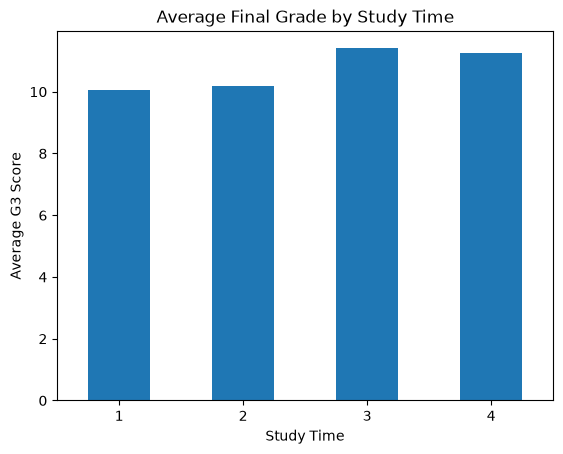

In [156]:
# Visualize the relationship between study time and final grade

import matplotlib.pyplot as plt

study_time_analysis.plot(kind="bar")

plt.title("Average Final Grade by Study Time")
plt.xlabel("Study Time")
plt.ylabel("Average G3 Score")
plt.xticks(rotation=0)
plt.show()

### 📌 Key Insight

Students with higher study time generally show better average final grades.

- Study time 1 → Average G3: 10.05
- Study time 2 → Average G3: 10.17
- Study time 3 → Average G3: 11.40
- Study time 4 → Average G3: 11.26

The results suggest that dedicating more time to studying is generally associated with stronger academic performance. However, the slight decline from study time 3 to 4 indicates that study time alone may not fully determine final grades.

## 🎓 Test Preparation and Academic Performance

Next, we examine whether completing the test preparation course is associated with higher final grades (G3).

This analysis helps us understand whether additional academic preparation may contribute to better student performance.

In [157]:
# Calculate average final grade based on test preparation course

test_prep_analysis = maths_df.groupby("paid")["G3"].mean()

print(test_prep_analysis)

paid
no      9.985981
yes    10.922652
Name: G3, dtype: float64


In [158]:
# Calculate average final grade based on extra educational support

support_analysis = maths_df.groupby("schoolsup")["G3"].mean()

print(support_analysis)

schoolsup
no     10.561047
yes     9.431373
Name: G3, dtype: float64


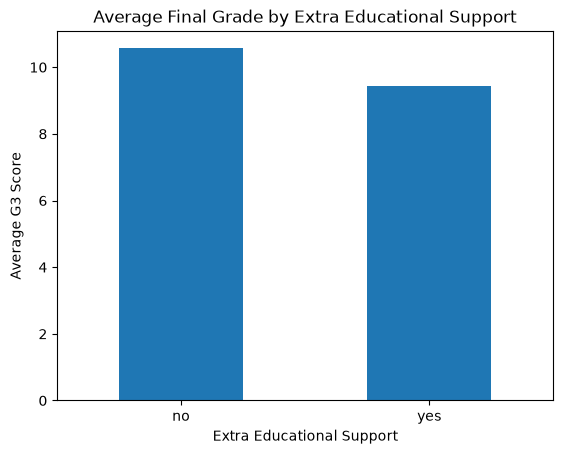

In [159]:
# Visualize average final grade by educational support

support_analysis.plot(kind="bar")

plt.title("Average Final Grade by Extra Educational Support")
plt.xlabel("Extra Educational Support")
plt.ylabel("Average G3 Score")
plt.xticks(rotation=0)
plt.show()

### 📌 Key Insight

Students receiving extra educational support have a lower average final grade than students who do not receive additional support.

- No support → Average G3: ~10.55
- Extra support → Average G3: ~9.44

This does not mean that extra support negatively affects performance. Students who are struggling academically may be more likely to receive additional support.

Therefore, extra educational support may be an indicator of students who need greater academic assistance.

## 📚 Previous Failures and Academic Performance

Next, we examine whether students with previous course failures tend to have lower final grades (G3).

This analysis helps identify whether previous academic difficulties are associated with current student performance.

In [160]:
# Calculate the average final grade for each previous-failure group
failure_analysis = maths_df.groupby("failures")["G3"].mean()

print(failure_analysis)

failures
0    11.253205
1     8.120000
2     6.235294
3     5.687500
Name: G3, dtype: float64


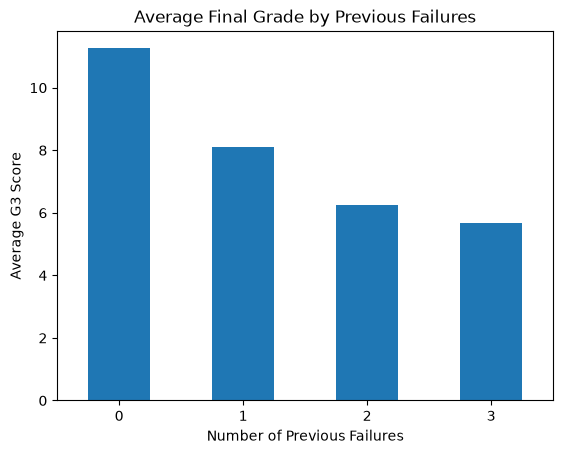

In [161]:
# Plot average final grade by number of previous failures
failure_analysis.plot(kind="bar")

plt.title("Average Final Grade by Previous Failures")
plt.xlabel("Number of Previous Failures")
plt.ylabel("Average G3 Score")
plt.xticks(rotation=0)

plt.show()

## 📌 Key Insight

Students with no previous failures generally achieve higher average final grades than students with one or more previous failures.

This suggests that previous academic difficulties may be associated with weaker current performance.

However, previous failures should be treated as an indicator rather than a direct cause of lower grades, as other factors may also influence academic outcomes.

In [162]:
# Check all column names in the dataset

print(maths_df.columns.tolist())

['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu', 'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime', 'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2', 'G3']


## 🎓 Higher Education Aspiration and Academic Performance

Next, we examine whether students' aspirations to pursue higher education are associated with their final grades (G3).

This analysis helps us understand whether students who plan to continue their education tend to achieve different academic outcomes.

In [163]:
# Calculate the average final grade for each higher education aspiration group

higher_analysis = maths_df.groupby("higher")["G3"].mean()

print(higher_analysis)

higher
no      6.800
yes    10.608
Name: G3, dtype: float64


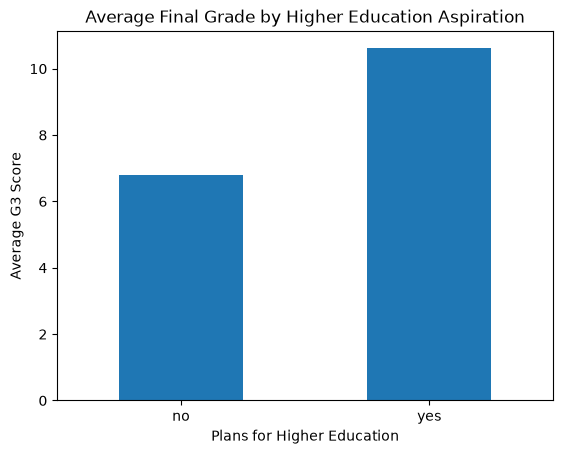

In [164]:
# Visualize average final grade by higher education aspiration

higher_analysis.plot(kind="bar")

plt.title("Average Final Grade by Higher Education Aspiration")
plt.xlabel("Plans for Higher Education")
plt.ylabel("Average G3 Score")
plt.xticks(rotation=0)

plt.show()

##  📌Key Insight:                                                                                                                                     
Students who plan to pursue higher education achieve substantially higher average final grades than students who do not. This suggests that educational aspirations may be associated with stronger academic performance. However, this is an association and does not necessarily imply that having higher education plans directly causes better grades.

## Gender and Academic Performance

Next, we examine whether students' gender is associated with their final grade (G3).

This helps identify whether there are differences in average academic performance between male and female students.

In [165]:
# Calculate the average final grade for each gender
gender_analysis = maths_df.groupby("sex")["G3"].mean()

print(gender_analysis)

sex
F     9.966346
M    10.914439
Name: G3, dtype: float64


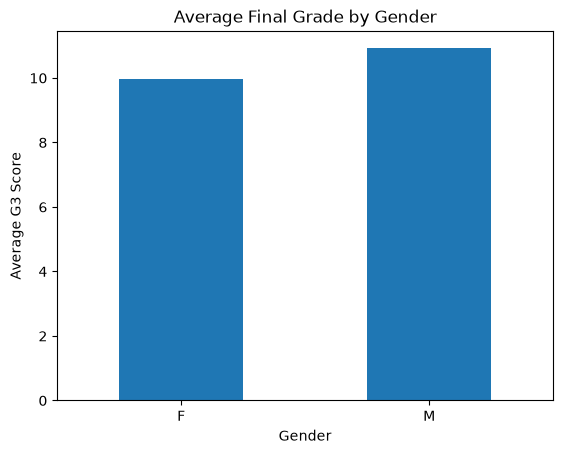

In [166]:
# Create a bar chart
gender_analysis.plot(kind="bar")

plt.title("Average Final Grade by Gender")
plt.xlabel("Gender")
plt.ylabel("Average G3 Score")
plt.xticks(rotation=0)

plt.show()

## 📌 Key Insight

Male students have a slightly higher average final grade than female students in this dataset.

This indicates a small difference in academic performance by gender. However, gender alone does not determine academic outcomes, as other factors may also influence students' grades.

## Parental Education and Academic Performance

Next, we examine whether parents' education level is associated with students' final grades (G3).

This helps us understand whether students from different parental education backgrounds show differences in academic performance.

In [167]:
# Calculate the average final grade for each parental education level
parent_education_analysis = maths_df.groupby("Fedu")["G3"].mean()

print(parent_education_analysis)

Fedu
0    13.000000
1     9.158537
2    10.260870
3    10.660000
4    11.364583
Name: G3, dtype: float64


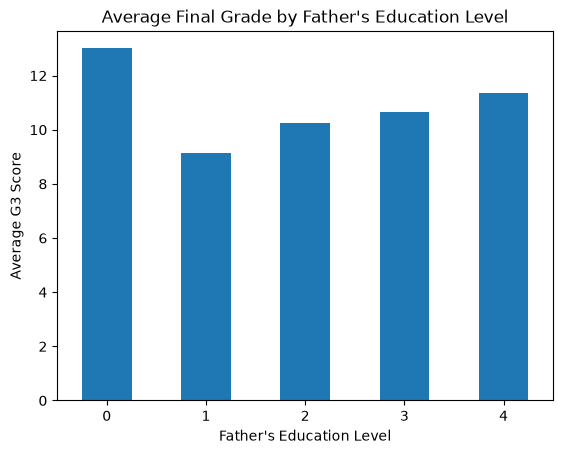

In [168]:
# Create a bar chart
parent_education_analysis.plot(kind="bar")

plt.title("Average Final Grade by Father's Education Level")
plt.xlabel("Father's Education Level")
plt.ylabel("Average G3 Score")
plt.xticks(rotation=0)

plt.show()

## 📌 Key Insight

Students' average final grades vary across different parental education levels.

The results do not show a consistent upward trend, suggesting that father's education level alone may not strongly determine students' academic performance.

Other factors may also play an important role in students' final grades.

In [169]:
# Calculate the average final grade for each mother's education level
mother_education_analysis = maths_df.groupby("Medu")["G3"].mean()

print(mother_education_analysis)


Medu
0    13.000000
1     8.677966
2     9.728155
3    10.303030
4    11.763359
Name: G3, dtype: float64


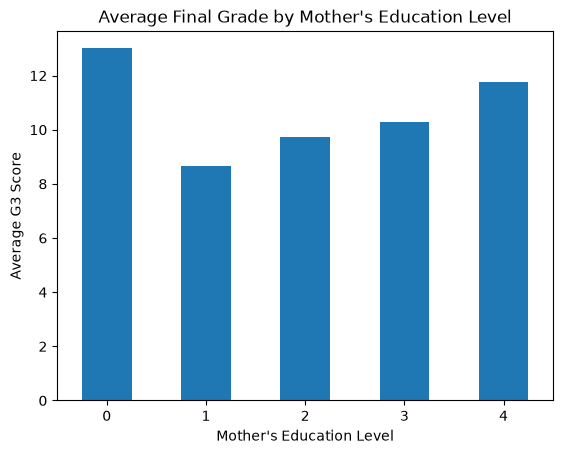

In [170]:
# Create a bar chart
mother_education_analysis.plot(kind="bar")

plt.title("Average Final Grade by Mother's Education Level")
plt.xlabel("Mother's Education Level")
plt.ylabel("Average G3 Score")
plt.xticks(rotation=0)

plt.show()

## 📚 Mother's Education Level and Academic Performance

We examine whether a mother's education level is associated with students' final grades (G3).

### 📌 Key Insight

Students' average final grades vary across different levels of mother's education.

The relationship is not strictly linear, indicating that a higher parental education level does not always correspond to higher student performance in this dataset.

Therefore, mother's education level may be associated with academic outcomes, but it should not be considered a direct cause of students' grades.

## ⏰ Study Time and Academic Performance

Next, we analyze whether students who spend more time studying tend to achieve higher final grades (G3).

This analysis helps identify whether study time is associated with students' academic performance.

In [171]:
# Calculate the average final grade for each study-time group
study_time_analysis = maths_df.groupby("studytime")["G3"].mean()

print(study_time_analysis)

studytime
1    10.047619
2    10.171717
3    11.400000
4    11.259259
Name: G3, dtype: float64


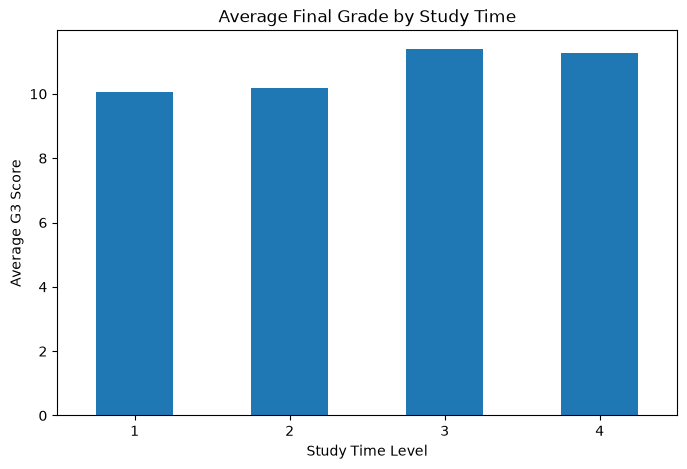

In [172]:
# Plot average final grade by study time

study_time_analysis.plot(kind="bar", figsize=(8, 5))

plt.title("Average Final Grade by Study Time")
plt.xlabel("Study Time Level")
plt.ylabel("Average G3 Score")
plt.xticks(rotation=0)

plt.show()

## ⏰ Study Time and Academic Performance

We examine whether the amount of time students spend studying is associated with their final grades (G3).

### 📌 Key Insight

Students with higher study-time levels generally have higher average final grades.

- Study Time 1 → Average G3: ~10.0
- Study Time 2 → Average G3: ~10.1
- Study Time 3 → Average G3: ~11.4
- Study Time 4 → Average G3: ~11.3

This suggests that greater study time is associated with better academic performance.

However, the relationship is not perfectly linear, as students in Study Time 4 have a slightly lower average than those in Study Time 3. Therefore, study time should be considered an associated factor rather than a direct cause of higher grades.

## 📅 Absences and Academic Performance

Next, we examine whether the number of school absences is associated with students' final grades (G3).

This analysis helps us understand whether attendance patterns are related to academic performance.

In [173]:
# Group students based on their number of absences

maths_df["absence_group"] = pd.cut(
    maths_df["absences"],
    bins=[-1, 5, 10, 20, float("inf")],
    labels=["0–5", "6–10", "11–20", "20+"]
)

# Calculate average final grade for each absence group

absence_group_analysis = maths_df.groupby(
    "absence_group", observed=True
)["G3"].mean()

print(absence_group_analysis)

absence_group
0–5      10.168675
6–10     11.400000
11–20    10.117647
20+      10.266667
Name: G3, dtype: float64


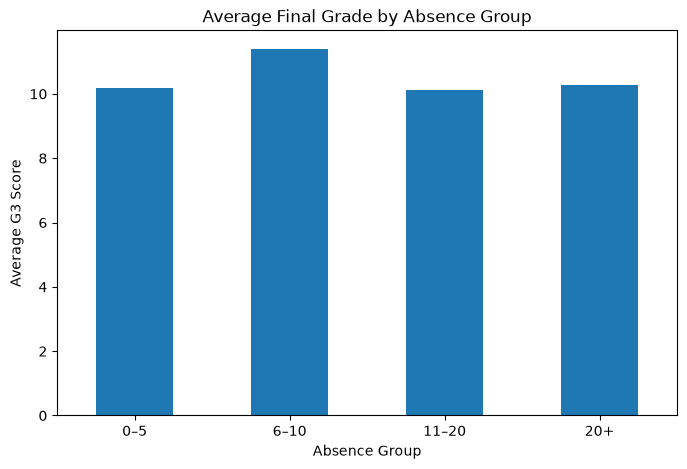

In [174]:
# Plot average final grade by absence group

absence_group_analysis.plot(kind="bar", figsize=(8, 5))

plt.title("Average Final Grade by Absence Group")
plt.xlabel("Absence Group")
plt.ylabel("Average G3 Score")
plt.xticks(rotation=0)

plt.show()

## 📅 Absences and Academic Performance

### 📌 Key Insight

Students with 0–5 absences have an average final grade of around 10.2, while students with 6–10 absences have the highest average at around 11.4.

The relationship between absences and final grades is not strictly linear. Students with very high absences (11–20 and 20+) have slightly lower average grades.

This suggests that excessive absenteeism may be associated with weaker academic performance. However, absence alone does not necessarily cause lower grades, as other factors may also influence student outcomes.

## 🌐 Internet Access and Academic Performance

Next, we examine whether students with internet access at home have different average final grades compared with students without internet access.

This analysis helps identify whether access to online learning resources is associated with academic performance.

In [175]:
# Calculate average final grade by internet access

internet_analysis = maths_df.groupby("internet")["G3"].mean()

print(internet_analysis)

internet
no      9.409091
yes    10.617021
Name: G3, dtype: float64


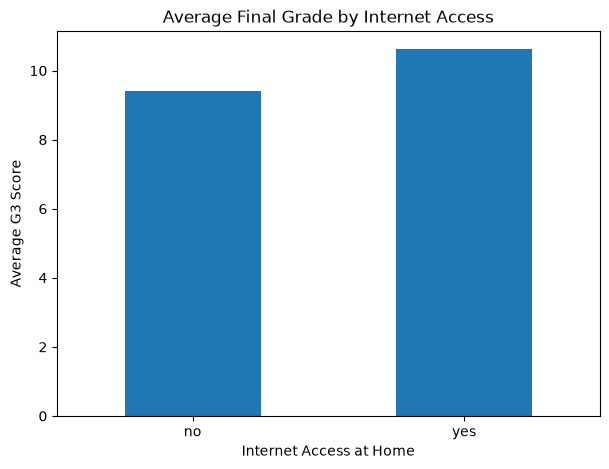

In [176]:
# Plot average final grade by internet access

internet_analysis.plot(kind="bar", figsize=(7, 5))

plt.title("Average Final Grade by Internet Access")
plt.xlabel("Internet Access at Home")
plt.ylabel("Average G3 Score")
plt.xticks(rotation=0)

plt.show()

### 📌 Key Insight

Students with internet access at home have a higher average final grade (G3) than students without internet access.

This suggests that access to the internet may be associated with better academic performance, potentially because students have greater access to online learning resources and study materials.

However, this is an association and does not necessarily imply that internet access directly causes higher grades.

## 💰 Paid Extra Educational Support and Academic Performance

Next, we examine whether receiving paid extra educational support is associated with students' final grades (G3).

This analysis helps determine whether students who receive additional paid educational support tend to achieve different academic outcomes.

In [177]:
# Calculate the average final grade for each paid-support group

paid_analysis = maths_df.groupby("paid")["G3"].mean()

print(paid_analysis)

paid
no      9.985981
yes    10.922652
Name: G3, dtype: float64


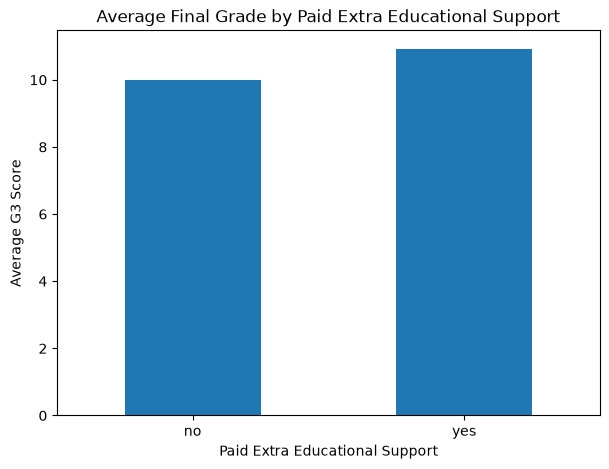

In [178]:
paid_analysis.plot(kind="bar", figsize=(7, 5))

plt.title("Average Final Grade by Paid Extra Educational Support")
plt.xlabel("Paid Extra Educational Support")
plt.ylabel("Average G3 Score")
plt.xticks(rotation=0)

plt.show()

### 📌 Key Insight

Students who receive paid extra educational support have a slightly higher average final grade than students who do not.

This suggests that additional educational support may be associated with improved academic performance. However, the difference is relatively small, so paid support alone may not be a strong predictor of final grades.

## 🎯 Extracurricular Activities and Academic Performance

Next, we examine whether participation in extracurricular activities is associated with students' final grades (G3).

This analysis helps determine whether students who participate in extracurricular activities tend to achieve different academic outcomes.

In [179]:
# Calculate the average final grade for each extracurricular activity group

activities_analysis = maths_df.groupby("activities")["G3"].mean()

print(activities_analysis)

activities
no     10.340206
yes    10.487562
Name: G3, dtype: float64


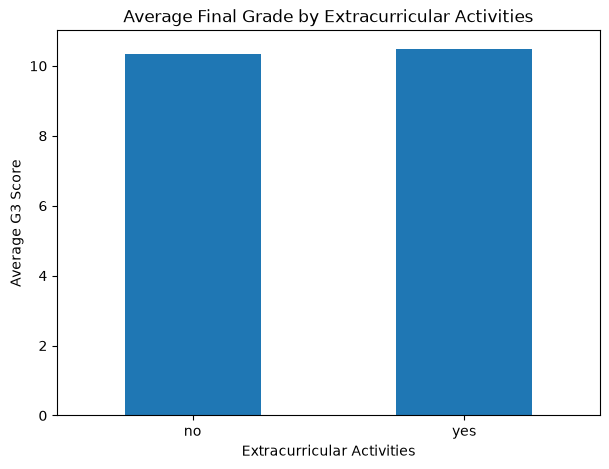

In [180]:
activities_analysis.plot(kind="bar", figsize=(7, 5))

plt.title("Average Final Grade by Extracurricular Activities")
plt.xlabel("Extracurricular Activities")
plt.ylabel("Average G3 Score")
plt.xticks(rotation=0)

plt.show()

### 📌 Key Insight

Students who participate in extracurricular activities have a slightly higher average final grade than students who do not.

However, the difference is very small, suggesting that extracurricular participation has a limited association with final academic performance in this dataset.

## 🏥 Health Status and Academic Performance

Next, we examine whether students' health status is associated with their final grades (G3).

This analysis helps identify whether students with different health conditions tend to have different academic outcomes.

In [181]:
# Calculate the average final grade for each health level

health_analysis = maths_df.groupby("health")["G3"].mean()

print(health_analysis)

health
1    11.872340
2    10.222222
3    10.010989
4    10.106061
5    10.397260
Name: G3, dtype: float64


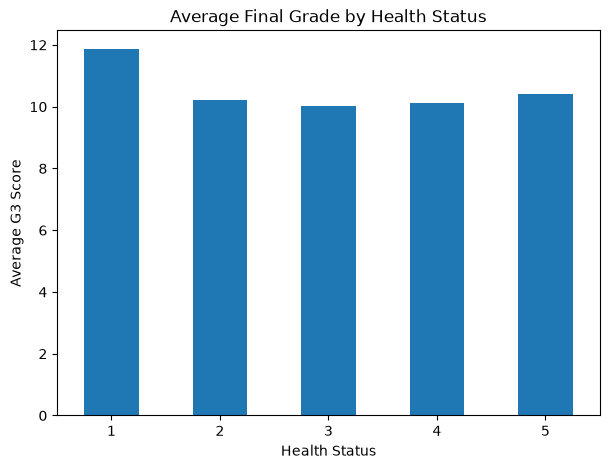

In [182]:
health_analysis.plot(kind="bar", figsize=(7, 5))

plt.title("Average Final Grade by Health Status")
plt.xlabel("Health Status")
plt.ylabel("Average G3 Score")
plt.xticks(rotation=0)

plt.show()

### 📌 Key Insight

Students with better health status tend to have slightly higher average final grades, while students with lower health status show more variation in academic performance.

However, the relationship is not perfectly consistent across all health levels, suggesting that health status alone is not a strong predictor of final grades in this dataset.

## 📈 Student Performance Trend Across Academic Periods

Next, we compare students' average grades across the first period (G1), second period (G2), and final grade (G3).

This analysis helps identify how student performance changes over the course of the academic year.

In [183]:
# Calculate average scores across all three academic periods

grade_trend = maths_df[["G1", "G2", "G3"]].mean()

print(grade_trend)

G1    10.908861
G2    10.713924
G3    10.415190
dtype: float64


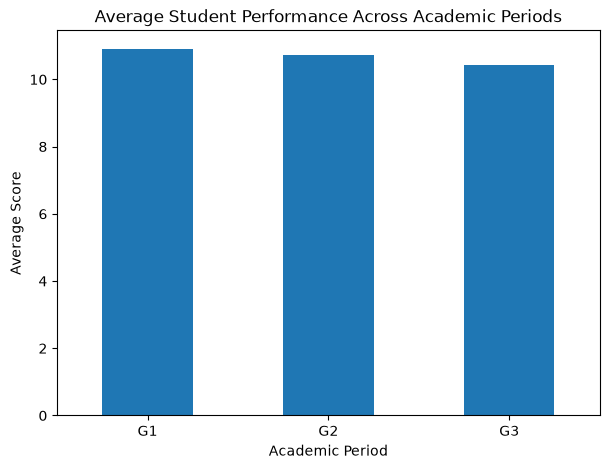

In [184]:
grade_trend.plot(kind="bar", figsize=(7, 5))

plt.title("Average Student Performance Across Academic Periods")
plt.xlabel("Academic Period")
plt.ylabel("Average Score")
plt.xticks(rotation=0)

plt.show()

## Attendance and Academic Performance

### Objective
Analyze whether student attendance is associated with academic performance.

### Business Question
> Do students with higher attendance tend to achieve better final grades?

This analysis will help identify whether attendance can be used as an early indicator of student academic performance.

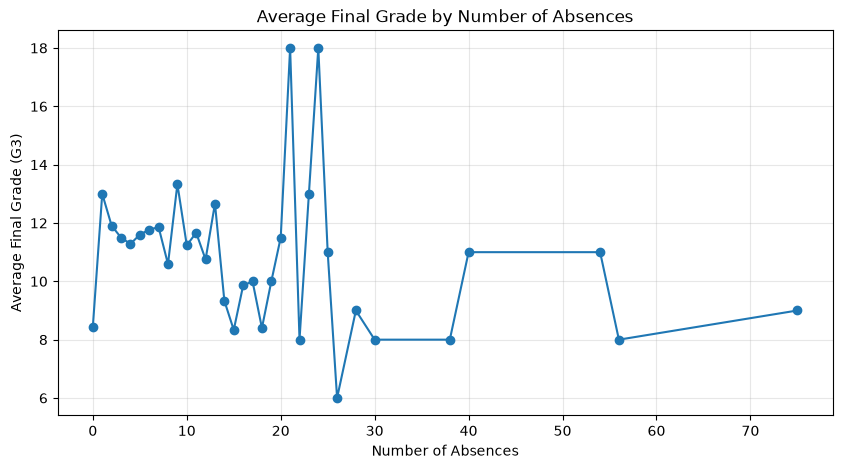

In [186]:
# Calculate average final grade for each absence level
absence_performance = maths_df.groupby("absences")["G3"].mean()

# Plot the relationship
plt.figure(figsize=(10, 5))

plt.plot(
    absence_performance.index,
    absence_performance.values,
    marker="o"
)

plt.title("Average Final Grade by Number of Absences")
plt.xlabel("Number of Absences")
plt.ylabel("Average Final Grade (G3)")
plt.grid(True, alpha=0.3)

plt.show()

## Attendance Impact on Academic Performance

### Key Finding

Student performance does not show a simple linear relationship with the number of absences.

Individual absence levels show considerable variation, particularly where fewer students are represented. Therefore, grouping students into broader absence categories provides a more reliable view of attendance patterns.

### Business Insight

Attendance alone may not be sufficient to predict academic performance. Other factors such as study time, parental education, internet access, and extracurricular participation may also influence student outcomes.

In [187]:
# Calculate correlation between absences and final grade
attendance_correlation = maths_df["absences"].corr(maths_df["G3"])

print("Correlation between absences and final grade:", round(attendance_correlation, 2))

Correlation between absences and final grade: 0.03


## Correlation Between Absences and Final Grade

The correlation between the number of absences and final grade (G3) is **0.03**.

This indicates an almost negligible linear relationship between absences and final academic performance in the dataset.

### Business Insight

Higher absenteeism does not consistently correspond to lower final grades. Therefore, absence count alone may not be a reliable predictor of student performance.

Other factors such as study time, parental education, test preparation, and access to learning resources should also be considered when identifying students at academic risk.

In [188]:
# Identify students who are at academic risk
# Students with a final grade (G3) below 10 are considered at risk

at_risk_students = maths_df[maths_df["G3"] < 10]

print("Number of students at academic risk:", len(at_risk_students))
print("Percentage of students at academic risk:",
      round(len(at_risk_students) / len(maths_df) * 100, 2), "%")

Number of students at academic risk: 130
Percentage of students at academic risk: 32.91 %


In [189]:
# Compare key academic factors for at-risk students

print("Average absences:")
print("At-risk students:", round(at_risk_students["absences"].mean(), 2))
print("All students:", round(maths_df["absences"].mean(), 2))

print("\nAverage study time:")
print("At-risk students:", round(at_risk_students["studytime"].mean(), 2))
print("All students:", round(maths_df["studytime"].mean(), 2))

print("\nAverage previous failures:")
print("At-risk students:", round(at_risk_students["failures"].mean(), 2))
print("All students:", round(maths_df["failures"].mean(), 2))

Average absences:
At-risk students: 6.76
All students: 5.71

Average study time:
At-risk students: 1.95
All students: 2.04

Average previous failures:
At-risk students: 0.69
All students: 0.33


In [190]:
# Compare academic risk by number of previous failures

failure_risk = (
    maths_df.groupby("failures")["G3"]
    .agg(["mean", "count"])
    .reset_index()
)

failure_risk["at_risk_percentage"] = (
    maths_df.groupby("failures")["G3"]
    .apply(lambda x: (x < 10).mean() * 100)
    .values
)

failure_risk

,failures,mean,count,at_risk_percentage
0,0,11.253205,312,25.000000
1,1,8.120000,50,52.000000
2,2,6.235294,17,82.352941
3,3,5.687500,16,75.000000


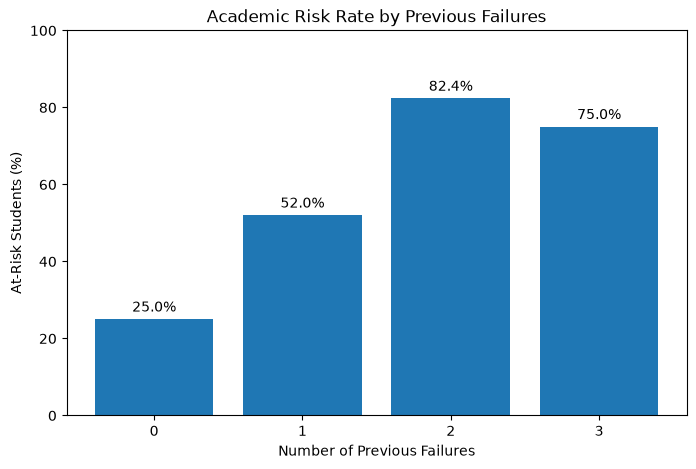

In [191]:
# Visualize academic risk by previous failures

plt.figure(figsize=(8, 5))

plt.bar(
    failure_risk["failures"].astype(str),
    failure_risk["at_risk_percentage"]
)

plt.title("Academic Risk Rate by Previous Failures")
plt.xlabel("Number of Previous Failures")
plt.ylabel("At-Risk Students (%)")
plt.ylim(0, 100)

# Add percentage labels
for i, value in enumerate(failure_risk["at_risk_percentage"]):
    plt.text(i, value + 2, f"{value:.1f}%", ha="center")

plt.show()

In [192]:
# Analyze the relationship between study time and final grade

studytime_performance = (
    maths_df.groupby("studytime")["G3"]
    .agg(["mean", "count"])
    .reset_index()
)

studytime_performance

,studytime,mean,count
0,1,10.047619,105
1,2,10.171717,198
2,3,11.400000,65
3,4,11.259259,27


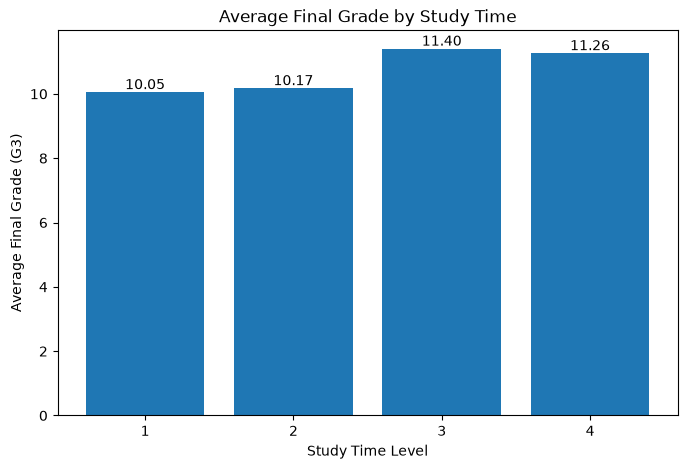

In [193]:
# Plot average final grade by study time

plt.figure(figsize=(8, 5))

plt.bar(
    studytime_performance["studytime"],
    studytime_performance["mean"]
)

plt.title("Average Final Grade by Study Time")
plt.xlabel("Study Time Level")
plt.ylabel("Average Final Grade (G3)")
plt.xticks([1, 2, 3, 4])

# Add values on top of bars
for x, y in zip(studytime_performance["studytime"], studytime_performance["mean"]):
    plt.text(x, y + 0.1, f"{y:.2f}", ha="center")

plt.show()

## Study Time and Academic Performance

Students with higher study-time levels generally achieved higher average final grades.

- Study Time 1: 10.05
- Study Time 2: 10.17
- Study Time 3: 11.40
- Study Time 4: 11.26

### Business Insight

Students in the higher study-time groups showed better average academic performance. However, the difference between study-time levels 3 and 4 is small, suggesting that simply increasing study time does not necessarily lead to proportionally higher grades.

Study time can therefore be considered as one factor associated with academic performance, but other factors should also be considered when identifying students who may need academic support.

In [195]:
# Analyze the relationship between extra educational support and final grade

support_performance = (
    maths_df.groupby("schoolsup")["G3"]
    .agg(["mean", "count"])
    .reset_index()
)

support_performance

,schoolsup,mean,count
0,no,10.561047,344
1,yes,9.431373,51


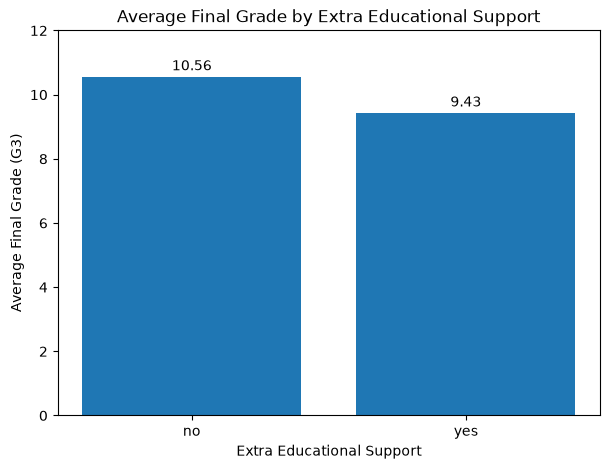

In [196]:
# Visualize the relationship between extra educational support and final grade

plt.figure(figsize=(7, 5))

bars = plt.bar(
    support_performance["schoolsup"],
    support_performance["mean"]
)

plt.title("Average Final Grade by Extra Educational Support")
plt.xlabel("Extra Educational Support")
plt.ylabel("Average Final Grade (G3)")
plt.ylim(0, 12)

# Add values on top of bars
for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.2,
        f"{bar.get_height():.2f}",
        ha="center"
    )

plt.show()

## Extra Educational Support and Academic Performance

Students receiving extra educational support had a lower average final grade (9.43) compared with students who did not receive additional support (10.56).

### Business Insight

Students receiving extra educational support appear to be a higher-risk group in this dataset. However, this does not mean that the support itself causes lower grades. Instead, students who are already struggling academically may be more likely to receive additional support.

This suggests that academic support programs should be combined with early identification of struggling students and targeted interventions.

# Final Exploratory Data Analysis Summary

## Key Findings

1. **Academic Risk**
   - 130 students, representing **32.91%** of the dataset, have a final grade below 10.
   - This indicates that nearly one-third of students may require additional academic attention.

2. **Attendance and Performance**
   - The correlation between absences and final grade is only **0.03**.
   - This indicates an almost negligible linear relationship between absence count and final academic performance.
   - Therefore, absences alone should not be used to identify students at academic risk.

3. **Previous Academic Failures**
   - Students with previous failures showed substantially higher academic risk.
   - The academic-risk rate increased from **25%** for students with no previous failures to **82.4%** for students with two previous failures.
   - Previous academic performance is therefore a stronger risk indicator than absence count.

4. **Study Time**
   - Average final grades generally increased with higher study-time levels.
   - Students at study-time level 3 achieved the highest average grade of **11.40**.
   - However, the difference between study-time levels 3 and 4 was small, suggesting that simply increasing study time does not guarantee proportionally higher grades.

5. **Extra Educational Support**
   - Students receiving extra educational support had a lower average final grade (**9.43**) than students who did not receive support (**10.56**).
   - This should not be interpreted as support causing lower grades.
   - Instead, students who are already struggling may be more likely to receive additional support.

## Overall Conclusion

The analysis shows that **previous academic failures and study time provide more meaningful signals of academic performance than absence count alone**.

A student's academic risk should therefore be evaluated using multiple factors rather than relying on a single indicator.

These findings can help educational institutions identify students who may benefit from **early intervention, targeted academic support, and closer monitoring**.